In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from disba import PhaseDispersion
#import project_utils.py

In [10]:
def forward_model(thickness, vp, vs, rho, period):
    # Creates a PhaseDispersion object - gives 1D velocity based on thickness/vs/vp/density
    pd = PhaseDispersion(thickness, vp, vs, rho)
    return pd(period, mode=0, wave="rayleigh")

## True Model
Assumed 2 layers and a half space to start


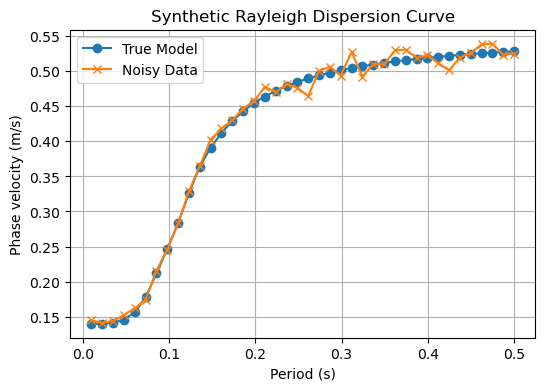

In [19]:
# units per disba documentation
# thickness (km)
thickness = [0.005, 0.010, 0]

# s-wave p-wave velocities (km/s)
vs_true = [.150, .300, 0.600]
vp_true = [.300, .600, 1.200]
# density (g/cm^3)
rho = [1.8, 1.9, 2.0]
# period[s]
period = np.linspace(0.01, 0.5, 40)

truemodel = forward_model(thickness, vp_true, vs_true, rho, period)

np.random.seed(0) # this keeps the random noise consistent across runs for reproducibility

dobs = truemodel.velocity
noise_level = 0.02
dobs_noisy= dobs + noise_level * dobs * np.random.randn(len(dobs))

T = truemodel.period

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o", label="True Model")
plt.plot(T, dobs_noisy, marker="x", label="Noisy Data")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (m/s)")
plt.title("Synthetic Rayleigh Dispersion Curve")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
def objective_function(beta, dpred, dobs, vs):
    phi_d = np.sum((dpred - dobs)**2)
    phi_m = np.sum(np.diff(vs)**2)
    phi = phi_d + beta * phi_m

    return phi, phi_d, phi_m

## First Trial (Steepest Descent)


In [80]:
thickness_first = [0.005, 0.010, 0.0] # fix for now - vary vs (perhaps change later)
vs_first = [0.18, 0.25, 0.50] # initial guess for Vs (km/s)
vp_first = [2*v for v in vs_first] # assume p-waves are 2x s-waves (generally true)
rho_first = [1.8, 1.9, 2.0] # minor impact on model, so assumed constant for now)

In [81]:
beta_first = 0.5 # regularization parameter - constant for now

dpred_first = forward_model(thickness_first, vp_first, vs_first, rho_first, period).velocity
obj_first = objective_function(beta_first, dpred_first, dobs_noisy, vs_first)


phi_first, phi_d_first, phi_m_first = objective_function(
    beta_first, dpred_first, dobs_noisy, vs_first)

## Steepest Descent / Gradient


In [82]:
def gradient_function(vs, thickness, rho, period, dobs, beta, dx=1e-4):
# Taking a small step (up and down) in a direction to determine gradient of objective function
    grad = [0.0] * len(vs)

    for i in range(len(vs)):
        vs_up = vs.copy()
        vs_up[i] += dx
        vs_down = vs.copy()
        vs_down[i] -= dx
        vp_up = [2*v for v in vs_up]
        vp_down = [2*v for v in vs_down]
        
        dpred_up = forward_model(thickness, vp_up, vs_up, rho, period).velocity
        phiup, _, _= objective_function(beta, dpred_up, dobs, vs_up)

        dpred_down = forward_model(thickness, vp_down, vs_down, rho, period).velocity
        phidown, _, _= objective_function(beta, dpred_down, dobs, vs_down)

        grad[i] = (phiup - phidown) / (2 * dx)
    return grad

In [88]:
def step_function(grad_vs, step, vs):
    #for 2 shear wave velocity system
    # no negative swave velocities - minimum 0.05 km/s (arbitrary)
    vs_new = [0.0] * len(vs)
    for i in range(len(vs)):
        vs_new [i]= max(vs[i] - step * grad_vs[i], 0.05)
    vp_new = [2*v for v in vs_new]
    return vs_new, vp_new

In [128]:
# while loop settings
step0 = 1e-2
i = 0
max_iter = 100
vs_current = vs_first.copy()
phi_current = phi_first
phi_diff = 999
tol_phi = 1e-5
phi_history = []

while (phi_diff > tol_phi) and (i < max_iter):
# halves the step until phi does not change much anymore (tol_phi)
    i += 1
    step = step0 #reset the steps at start of iteration
    n_half = 0 # counter for step halving

    grad_current = gradient_function(vs_current, thickness_first, rho_first, period, dobs_noisy, beta_first)

    while n_half < 10: 
        vs_trial_new, vp_trial_new = step_function(grad_current, step, vs_current)
        dpred_new = forward_model(thickness_first, vp_trial_new, vs_trial_new, rho_first, period).velocity
        phi_new, phi_d_new, phi_m_new = objective_function(beta_first, dpred_new, dobs_noisy, vs_trial_new)
        # took a step and then calculated objective function
        print(f"Iteration {i}: step={step:.2e}, phi={phi_new:.3e}, vs={vs_trial_new}")
        phi_history.append(phi_new)
    
        if phi_new < phi_current:
            #checks phi_new is smaller than phi_current and accepts changes if so
            phi_diff = abs(phi_new - phi_current)
            vs_current = vs_trial_new
            vp_current = vp_trial_new
            dpred_current = dpred_new
            phi_current = phi_new
            print(f"step accepted. phi_diff={phi_diff:.3e}")
            break
        #if phi_new > phi_current, spit the step and go again.
        step *= 0.5
        n_half += 1
        print(f"step failed. step={step:.3e}")
    if n_half == 10:
        print("No acceptable step found.")
        break

Iteration 1: step=1.00e-02, phi=1.267e-01, vs=[np.float64(0.18823103646042655), np.float64(0.27088038360871236), np.float64(0.5365755027219028)]
step accepted. phi_diff=1.400e-01
Iteration 2: step=1.00e-02, phi=8.647e-02, vs=[np.float64(0.1892553500844389), np.float64(0.27955999945202237), np.float64(0.5575821276835794)]
step accepted. phi_diff=4.020e-02
Iteration 3: step=1.00e-02, phi=7.325e-02, vs=[np.float64(0.18737326268288804), np.float64(0.28344508368290644), np.float64(0.5696738704417221)]
step accepted. phi_diff=1.322e-02
Iteration 4: step=1.00e-02, phi=6.785e-02, vs=[np.float64(0.18432559861183317), np.float64(0.28530585000937403), np.float64(0.5768357797860733)]
step accepted. phi_diff=5.400e-03
Iteration 5: step=1.00e-02, phi=6.501e-02, vs=[np.float64(0.18095652592311118), np.float64(0.28637062581927847), np.float64(0.5812652566160588)]
step accepted. phi_diff=2.844e-03
Iteration 6: step=1.00e-02, phi=6.320e-02, vs=[np.float64(0.1776709883655078), np.float64(0.28720521694061

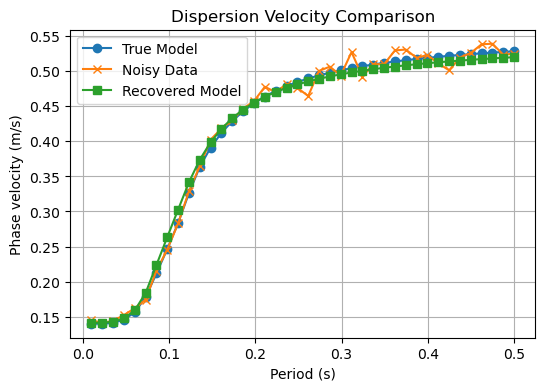

In [126]:
dpred_final = dpred_current.copy()

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o", label="True Model")
plt.plot(T, dobs_noisy, marker="x", label="Noisy Data")
plt.plot(T, dpred_final, marker="s", label="Recovered Model")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (m/s)")
plt.title("Dispersion Velocity Comparison")
plt.grid(True)
plt.legend()
plt.show()



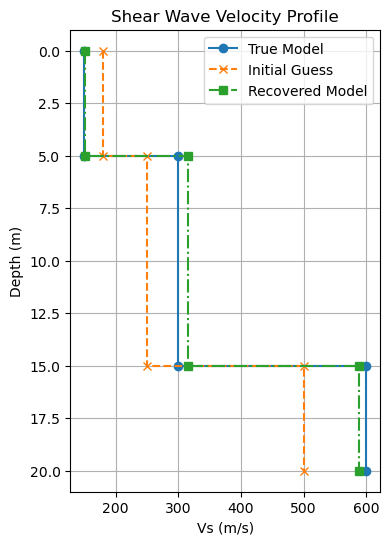

In [127]:
vs_true #true
vs_first #starting point
vs_final = vs_current.copy() #recovered

depth1 = thickness_first[0]
depth2 = depth1 + thickness_first[1]
depth3 = depth2 + 0.005 # halfspace

depth = [0, depth1, depth2, depth3]

def step_Vsplot(vs, depth):
    vs_plot =[vs[0], vs[0], vs[1], vs[1], vs[2], vs[2]]
    depth_plot = [depth[0], depth[1], depth[1], depth[2], depth[2], depth[3]]
    return vs_plot, depth_plot

# stepped velocity profile
vs_true_plot, depth_true_plot = step_Vsplot(vs_true, depth)
vs_first_plot, depth_first_plot = step_Vsplot(vs_first, depth)
vs_final_plot, depth_final_plot = step_Vsplot(vs_final, depth)

# convert to meters (more common than km)
vs_true_plot = [v * 1000 for v in vs_true_plot]
vs_first_plot = [v * 1000 for v in vs_first_plot]
vs_final_plot = [v * 1000 for v in vs_final_plot]
depth_true_plot = [d * 1000 for d in depth_true_plot]
depth_first_plot = [d * 1000 for d in depth_first_plot]
depth_final_plot = [d * 1000 for d in depth_final_plot]

plt.figure(figsize=(4,6))
plt.plot(vs_true_plot, depth_true_plot, label="True Model", marker="o")
plt.plot(vs_first_plot, depth_first_plot, label="Initial Guess", ls="--", marker="x")
plt.plot(vs_final_plot, depth_final_plot, label="Recovered Model", ls="-.", marker="s")
plt.gca().invert_yaxis()
plt.xlabel("Vs (m/s)")
plt.ylabel("Depth (m)")
plt.title("Shear Wave Velocity Profile")
plt.grid(True)
plt.legend()
plt.show()


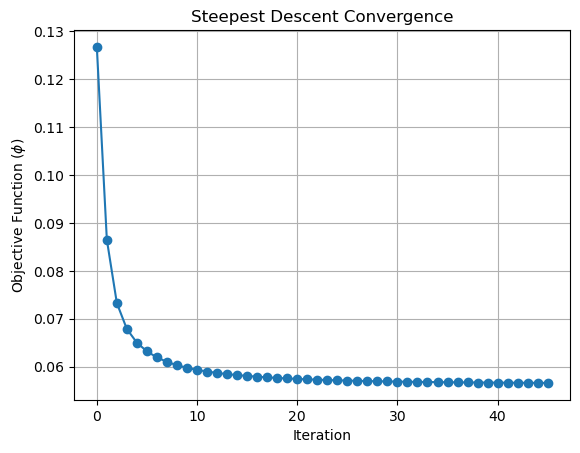

In [141]:
plt.plot(phi_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'Objective Function ($\phi$)')
plt.title('Steepest Descent Convergence')
plt.grid()
plt.show()

## Newton's Method

In [111]:
thickness_newton = [0.005, 0.010, 0.0]
vs_newton = [0.18, 0.25, 0.50]
vp_newton = [2*v for v in vs_newton]
rho_newton = [1.8, 1.9, 2.0]
beta_newton = 0.5

In [134]:
def hess_function(vs, thickness, rho, period, dobs, beta, dx=1e-4):
# Gemini: Taylor Series approx for 2nd derivative: [ f(x+h) - 2f(x) + f(x-h) ] / h^2
    hess = [0.0] * len(vs)
    vp = [2*v for v in vs]

    for i in range(len(vs)):
        vs_up = vs.copy()
        vs_up[i] += dx
        vs_down = vs.copy()
        vs_down[i] -= dx
        vp_up = [2*v for v in vs_up]
        vp_down = [2*v for v in vs_down]
            
        dpred_up = forward_model(thickness, vp_up, vs_up, rho, period).velocity
        phiup, _, _= objective_function(beta, dpred_up, dobs, vs_up)

        dpred_down = forward_model(thickness, vp_down, vs_down, rho, period).velocity
        phidown, _, _= objective_function(beta, dpred_down, dobs, vs_down)

        dpred_now = forward_model(thickness, vp, vs, rho, period).velocity
        phi, _, _ = objective_function(beta, dpred_now, dobs, vs)

        hess[i] = (phiup - 2*phi + phidown) / (dx**2)
    return hess

In [142]:
# initial gradients
grad_newton = gradient_function(vs_newton, thickness_newton, rho_newton, period, dobs_noisy, beta_newton)
hess_newton = hess_function(vs_newton, thickness_newton, rho_newton, period, dobs_noisy, beta_newton)

# initialize variables
vs_newton_now = vs_newton.copy()
step_newton = [0.0] * len(vs_newton)
vs_newton_update = [0.0] * len(vs_newton)


dpred_now = forward_model(thickness_newton, vp_newton, vs_newton, rho_newton, period).velocity
phi_now, _, _ = objective_function(beta_newton, dpred_now, dobs_noisy, vs_newton)

iter = 0
max_iter_newton = 100
phi_diff_newton = 9999
tol_phi_newton = 1e-5
tol_hess_newton = 1e-5
phi_newton_history = []
damping_factor = 0.8 # helped with stability

while (phi_diff_newton > tol_phi_newton) and (iter < max_iter_newton):
    iter+= 1

    for i in range(len(vs_newton)):
        # limits small hessian
        if hess_newton[i] > tol_hess_newton:
            step_newton[i] = -grad_newton[i] / hess_newton[i]
        else:
            step_newton[i] = 0
    
    vs_newton_update = [vs_newton_now[i] + damping_factor * step_newton[i] for i in range(len(vs_newton))]
    vp_newton_update = [2*v for v in vs_newton_update]
    dpred_update = forward_model(thickness_newton, vp_newton_update, vs_newton_update, rho_newton, period).velocity
    phi_update, _, _ = objective_function(beta_newton, dpred_update, dobs_noisy, vs_newton_update)

    phi_diff_newton = abs(phi_update - phi_now)
    print(f"Iteration {iter}: step={step_newton[i]:.2e}, phi={phi_update:.3e}, vs={vs_newton_update[i]}")
    phi_newton_history.append(phi_update)
    
    if phi_update <= phi_now:
        vs_newton_now = vs_newton_update
        vp_newton_now = vp_newton_update
        phi_now = phi_update
        grad_newton = gradient_function(vs_newton_now, thickness_newton, rho_newton, period, dobs_noisy, beta_newton)
        hess_newton = hess_function(vs_newton_now, thickness_newton, rho_newton, period, dobs_noisy, beta_newton)
        print(f"step accepted. phi_diff={phi_diff_newton:.3e}")
    else:
        print(f"step rejected. phi_diff={phi_diff_newton:.3e}")
        break

print(f"final vs = {vs_newton_now}, final phi = {phi_now:.3e}")

Iteration 1: step=2.63e-02, phi=1.737e-01, vs=0.5210199494380447
step accepted. phi_diff=9.294e-02
Iteration 2: step=3.85e-02, phi=9.418e-02, vs=0.5518278077711843
step accepted. phi_diff=7.955e-02
Iteration 3: step=2.11e-02, phi=7.374e-02, vs=0.5687339904438723
step accepted. phi_diff=2.044e-02
Iteration 4: step=1.63e-02, phi=6.367e-02, vs=0.5817470286827843
step accepted. phi_diff=1.007e-02
Iteration 5: step=5.20e-03, phi=6.041e-02, vs=0.5859034805765893
step accepted. phi_diff=3.260e-03
Iteration 6: step=4.38e-03, phi=5.880e-02, vs=0.5894076235297898
step accepted. phi_diff=1.609e-03
Iteration 7: step=1.05e-03, phi=5.778e-02, vs=0.5902500547632121
step accepted. phi_diff=1.014e-03
Iteration 8: step=-1.67e-04, phi=5.748e-02, vs=0.5901161040644646
step accepted. phi_diff=3.087e-04
Iteration 9: step=-5.47e-05, phi=5.723e-02, vs=0.5900723808126769
step accepted. phi_diff=2.430e-04
Iteration 10: step=-1.42e-04, phi=5.700e-02, vs=0.5899585321199382
step accepted. phi_diff=2.365e-04
Iterat

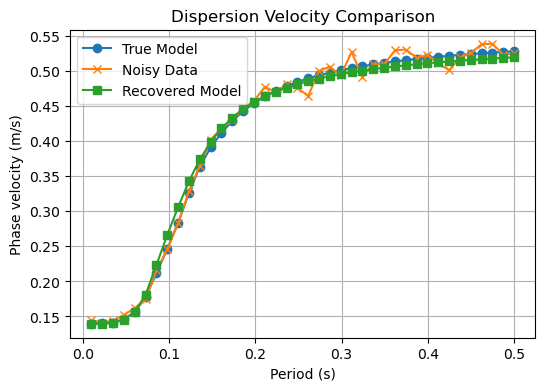

In [144]:
dpred_newtonfinal = forward_model(thickness_newton, vp_newton_now, vs_newton_now, rho_newton, period).velocity

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o", label="True Model")
plt.plot(T, dobs_noisy, marker="x", label="Noisy Data")
plt.plot(T, dpred_newtonfinal, marker="s", label="Recovered Model")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (m/s)")
plt.title("Dispersion Velocity Comparison")
plt.grid(True)
plt.legend()
plt.show()

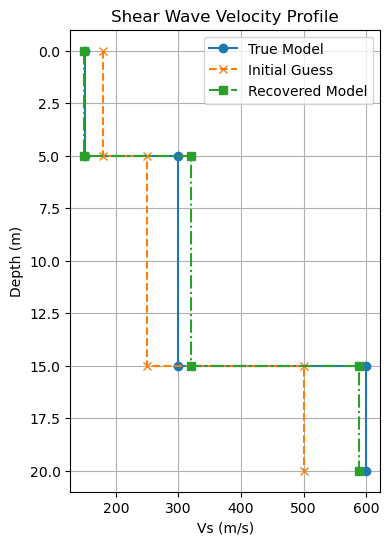

In [145]:
vs_true #true
vs_first #starting point
vs_newtonfinal = vs_newton_now.copy() #recovered

depth1 = thickness_first[0]
depth2 = depth1 + thickness_first[1]
depth3 = depth2 + 0.005 # halfspace

depth = [0, depth1, depth2, depth3]

# stepped velocity profile
vs_true_plot, depth_true_plot = step_Vsplot(vs_true, depth)
vs_first_plot, depth_first_plot = step_Vsplot(vs_first, depth)
vs_newtonfinal_plot, depth_newtonfinal_plot = step_Vsplot(vs_newtonfinal, depth)

# convert to meters (more common than km)
vs_true_plot = [v * 1000 for v in vs_true_plot]
vs_first_plot = [v * 1000 for v in vs_first_plot]
vs_newtonfinal_plot = [v * 1000 for v in vs_newtonfinal_plot]
depth_true_plot = [d * 1000 for d in depth_true_plot]
depth_first_plot = [d * 1000 for d in depth_first_plot]
depth_newtonfinal_plot = [d * 1000 for d in depth_newtonfinal_plot]

plt.figure(figsize=(4,6))
plt.plot(vs_true_plot, depth_true_plot, label="True Model", marker="o")
plt.plot(vs_first_plot, depth_first_plot, label="Initial Guess", ls="--", marker="x")
plt.plot(vs_newtonfinal_plot, depth_newtonfinal_plot, label="Recovered Model", ls="-.", marker="s")
plt.gca().invert_yaxis()
plt.xlabel("Vs (m/s)")
plt.ylabel("Depth (m)")
plt.title("Shear Wave Velocity Profile")
plt.grid(True)
plt.legend()
plt.show()


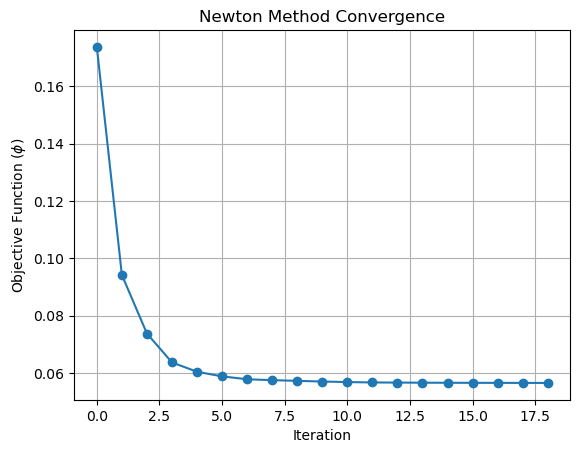

In [146]:
plt.plot(phi_newton_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'Objective Function ($\phi$)')
plt.title('Newton Method Convergence')
plt.grid()
plt.show()